# Matplotlib Fundamentals: Deep Dive

Dieses Notebook erklärt die grundlegenden Konzepte von Matplotlib im Detail:

1. **`plt.show()` vs. `fig.show()`** - Der wichtigste Unterschied zuerst!
2. **`np.linspace()`** - Wie man gleichmäßig verteilte Datenpunkte erstellt
3. **Figure und Axes Objekte** - Die Architektur von Matplotlib
4. **Wie Achsen (axes) automatisch erstellt werden**
5. **Arrays vs. Listen** - Warum man Arrays nicht einfach "mappen" kann

Jedes Konzept wird mit praktischen Beispielen und Visualisierungen erklärt.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

## 1. `np.linspace()` - Gleichmäßig verteilte Punkte

### Was macht `linspace()`?

`np.linspace(start, stop, num)` erstellt ein Array mit `num` gleichmäßig verteilten Werten zwischen `start` und `stop`.

### Warum brauchen wir das?

Für glatte Kurven brauchen wir viele Datenpunkte. Statt sie manuell zu schreiben, generiert `linspace()` sie automatisch.

In [3]:
# Beispiel 1: Wenige Punkte
x_wenig = np.linspace(0,10,2)  # 2 Punkte zwischen 0 und 10
y_axis = [1400,1500]
print("5 Punkte:")
print(x_wenig)
print(f"Abstand zwischen Punkten: {x_wenig[1] - x_wenig[0]}")

print("\n" + "="*50 + "\n")

# Beispiel 2: Viele Punkte
x_viel = np.linspace(0, 10, 11)  # 11 Punkte zwischen 0 und 10
print("11 Punkte:")
print(x_viel)
print(f"Abstand zwischen Punkten: {x_viel[1] - x_viel[0]}")

5 Punkte:
[ 0. 10.]
Abstand zwischen Punkten: 10.0


11 Punkte:
[ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Abstand zwischen Punkten: 1.0


In [4]:
x_wenig

array([ 0., 10.])

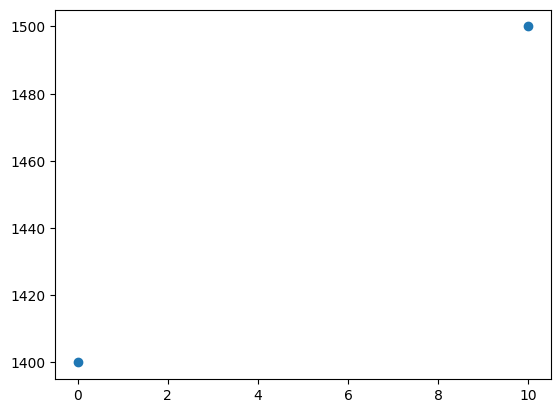

In [5]:
plt.scatter(x_wenig, y_axis) # 2 dimensional - 2 arrays als Parameter
#==

#fig.scatter(x_wenig,y_axis)
#(0, 0); (10, 0)

## ⚠️ WICHTIG: `plt.show()` vs. `fig.show()` - Was ist der Unterschied?

### Die Verwirrung:

Wenn du mit Matplotlib arbeitest, siehst du oft zwei verschiedene Methoden, um Plots anzuzeigen:

```python
# Methode 1
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [1, 2, 3])
plt.show()  # ← Modul-Funktion

# Methode 2
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [1, 2, 3])
fig.show()  # ← Objekt-Methode
```

### Warum `plt.show()` und NICHT `fig.show()`?

#### 1. **`plt.show()` ist die offizielle, empfohlene Methode**

- `plt` ist das **pyplot Modul** von Matplotlib
- `plt.show()` ist eine **Modul-Funktion**, die alle offenen Figures verwaltet
- Sie ist speziell für interaktive Umgebungen (wie Jupyter) optimiert

#### 2. **`fig.show()` ist eine Objekt-Methode mit Einschränkungen**

- `fig` ist ein **Figure-Objekt**
- `fig.show()` ist eine **Objekt-Methode**, die nur diese eine Figure betrifft
- Sie verhält sich in Jupyter Notebooks anders als erwartet
- Sie kann zu Problemen mit dem Figure-Management führen

### Was passiert technisch?

```python
# plt.show() macht:
# 1. Zeigt ALLE offenen Figures an
# 2. Wartet auf Benutzerinteraktion (in interaktiven Backends)
# 3. Schließt die Figures nach dem Anzeigen
# 4. Gibt Speicher frei

# fig.show() macht:
# 1. Zeigt NUR diese eine Figure an
# 2. Schließt die Figure NICHT automatisch
# 3. Figure bleibt im Speicher
# 4. Kann zu Memory-Leaks führen
```

### Praktischer Vergleich:

| Aspekt | `plt.show()` | `fig.show()` |
|--------|-------------|-------------|
| **Empfohlen?** | ✅ Ja | ❌ Nein |
| **Jupyter Notebooks** | ✅ Funktioniert perfekt | ⚠️ Kann Probleme machen |
| **Speicherverwaltung** | ✅ Automatisch | ❌ Manuell nötig |
| **Mehrere Figures** | ✅ Zeigt alle | ❌ Nur eine |
| **Schließt Figure** | ✅ Ja | ❌ Nein |

### Die Regel:

```python
# ✅ IMMER SO:
fig, ax = plt.subplots()
ax.plot(x, y)
plt.show()  # Nutze plt.show()

# ❌ NICHT SO:
fig, ax = plt.subplots()
ax.plot(x, y)
fig.show()  # Vermeide fig.show()

# ✅ ODER IN JUPYTER (automatische Anzeige):
fig, ax = plt.subplots()
ax.plot(x, y)
# Kein show() nötig - wird automatisch angezeigt
```

### Warum ist das wichtig?

1. **Konsistenz**: Dein Code funktioniert überall gleich
2. **Keine Memory-Leaks**: Figures werden ordentlich geschlossen
3. **Best Practice**: Folgt den offiziellen Matplotlib-Empfehlungen
4. **Weniger Bugs**: Vermeidet subtile Probleme mit Figure-Management

---

**💡 Merke dir:** Nutze immer `plt.show()`, nie `fig.show()`!

In [6]:
y_axis

[1400, 1500]

## 2. Figure und Axes - Die Matplotlib Architektur

### Die Hierarchie:

```
Figure (die gesamte Zeichenfläche)
  └── Axes (der Plotbereich mit x/y-Achsen)
       ├── x-Achse
       ├── y-Achse
       └── Plot-Elemente (Linien, Punkte, etc.)
```

### Wichtig zu verstehen:

- **Figure** = Das gesamte Fenster/Bild (wie ein Blatt Papier)
- **Axes** = Der eigentliche Plot-Bereich (wie ein Koordinatensystem auf dem Papier)
- Eine Figure kann mehrere Axes enthalten (Subplots)
- Axes ist NICHT die Achse (axis), sondern der gesamte Plot-Bereich!

## 3. Wie werden die Achsen (Axes) automatisch erstellt?

### Die Frage:
Woher weiß Matplotlib, welche Werte auf den Achsen angezeigt werden sollen?

### Die Antwort:
Matplotlib analysiert automatisch die Daten und setzt die Achsengrenzen basierend auf:
1. **Minimum der Daten** (mit etwas Puffer)
2. **Maximum der Daten** (mit etwas Puffer)

### Schauen wir uns das genau an:

Figure-Objekt: Figure(1000x600)
Axes-Objekt: Axes(0.125,0.11;0.775x0.77)

Figure Größe: [10.  6.] inches
Axes Position: Bbox(x0=0.125, y0=0.10999999999999999, x1=0.9, y1=0.88)


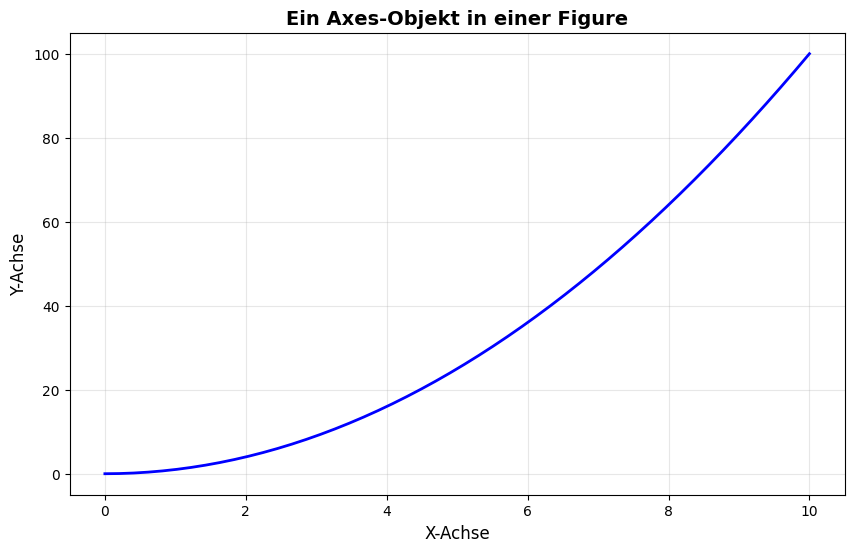

In [7]:
# Beispiel: Figure mit einem Axes
fig, ax = plt.subplots(figsize=(10, 6))

# Zeichne etwas
x = np.linspace(0, 10, 50)
y = x**2
ax.plot(x, y, linewidth=2, color='blue')
ax.set_xlabel('X-Achse', fontsize=12)
ax.set_ylabel('Y-Achse', fontsize=12)
ax.set_title('Ein Axes-Objekt in einer Figure', fontsize=14, weight='bold')
ax.grid(True, alpha=0.3)

# Zeige die Objekte
print(f"Figure-Objekt: {fig}")
print(f"Axes-Objekt: {ax}")
print(f"\nFigure Größe: {fig.get_size_inches()} inches")
print(f"Axes Position: {ax.get_position()}")

plt.show()  # ✅ Nutze plt.show(), nicht fig.show()!

## 6. Ticks verstehen und anpassen

### Was sind Ticks?

**Ticks** sind die **kleinen Markierungen** auf den Achsen, die zeigen, wo bestimmte Werte liegen.

```
Y-Achse
  |
100 ←  Tick (Markierung + Label)
  |
 75 ←  Tick
  |
 50 ←  Tick
  |
 25 ←  Tick
  |
  0 ←  Tick
  +----------→ X-Achse
    0  25  50  75  100
    ↑   ↑   ↑   ↑   ↑
    Ticks (Markierungen + Labels)
```

Jeder Tick besteht aus zwei Teilen:
1. **Tick-Position**: Wo die Markierung auf der Achse ist (z.B. bei 0, 25, 50)
2. **Tick-Label**: Der Text, der neben der Markierung steht (z.B. "0", "25", "50")

### Warum sind Ticks wichtig?

- Sie helfen dem Leser, **Werte abzulesen**
- Sie geben **Orientierung** im Plot
- Sie können **Einheiten** zeigen (%, €, km, etc.)
- Sie beeinflussen die **Lesbarkeit** des Plots

Gesetzte Ticks:
X-Ticks: [22 23 24 25 26 27 28 29 30 31 32]
Y-Ticks: [0.   0.25 0.5  0.75 1.  ]

Formatierte Y-Labels:
['0%', '25%', '50%', '75%', '100%']


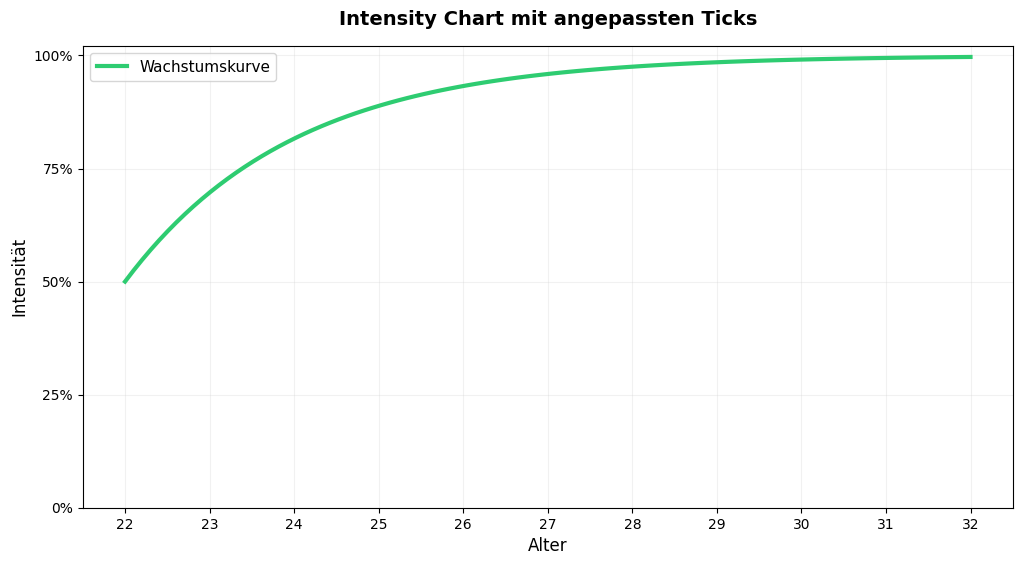


🎉 Perfekt! Du hast gelernt:
   ✅ Was Ticks sind (Markierungen auf Achsen)
   ✅ Wie man sie manuell setzt (set_xticks, set_yticks)
   ✅ Wie man sie mit linspace erstellt (gleichmäßig verteilt)
   ✅ Wie man Tick-Labels anpasst (Prozent, Euro, etc.)

   Du kannst jetzt professionelle Plots mit perfekten Ticks erstellen! 🚀


In [8]:
# Vollständiges Beispiel: Intensity Chart

# 1. Daten erstellen
x = np.linspace(22, 32, 100)
y = 0.5 + 0.5 * (1 - np.exp(-0.5 * (x - 22)))

# 2. Figure + Axes erstellen
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 3. Plotten
ax.plot(x, y, color='#2ecc71', linewidth=3, label='Wachstumskurve')

# 4. Ticks mit linspace setzen
x_ticks = np.arange(22, 33, 1)  # Jedes Jahr von 22 bis 32
y_ticks = np.linspace(0, 1, 5)  # 5 gleichmäßige Ticks von 0 bis 1
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)

print("Gesetzte Ticks:")
print(f"X-Ticks: {x_ticks}")
print(f"Y-Ticks: {y_ticks}\n")

# 5. Tick-Labels als Prozent formatieren
ax.set_yticklabels([f'{int(t*100)}%' for t in y_ticks])

print("Formatierte Y-Labels:")
print([f'{int(t*100)}%' for t in y_ticks])

# 6. Styling
ax.set_xlabel('Alter', fontsize=12)
ax.set_ylabel('Intensität', fontsize=12)
ax.set_title('Intensity Chart mit angepassten Ticks', fontsize=14, weight='bold', pad=15)
ax.grid(True, alpha=0.3, color='#d3d3d3')
ax.legend(fontsize=11)

# 7. Anzeigen
plt.show()

print("\n🎉 Perfekt! Du hast gelernt:")
print("   ✅ Was Ticks sind (Markierungen auf Achsen)")
print("   ✅ Wie man sie manuell setzt (set_xticks, set_yticks)")
print("   ✅ Wie man sie mit linspace erstellt (gleichmäßig verteilt)")
print("   ✅ Wie man Tick-Labels anpasst (Prozent, Euro, etc.)")
print("\n   Du kannst jetzt professionelle Plots mit perfekten Ticks erstellen! 🚀")

## 6.1 Automatische Ticks (Standard)

Matplotlib setzt **automatisch** Ticks basierend auf deinen Daten:

```python
ax.plot([1, 2, 3], [10, 20, 30])
# Matplotlib wählt automatisch sinnvolle Tick-Positionen
```

#### Wie entscheidet Matplotlib?

1. Schaut sich die **Min/Max-Werte** deiner Daten an
2. Wählt **runde Zahlen** (0, 5, 10, 20, 50, 100, etc.)
3. Versucht **5-10 Ticks** zu setzen (nicht zu viele, nicht zu wenige)
4. Passt sich an die **Größe des Plots** an

### 6.2 Ticks manuell setzen

Manchmal möchtest du die Ticks **selbst bestimmen**:

```python
# X-Achse Ticks setzen
ax.set_xticks([0, 1, 2, 3, 4, 5])

# Y-Achse Ticks setzen
ax.set_yticks([0, 25, 50, 75, 100])
```

#### Wann solltest du Ticks manuell setzen?

- Wenn du **spezifische Werte** hervorheben willst
- Wenn die automatischen Ticks **nicht passen**
- Wenn du **gleichmäßige Abstände** brauchst
- Wenn du **bestimmte Einheiten** zeigen willst (z.B. jedes Jahr, jeden Monat)

Automatische Ticks:
X: [-2.  0.  2.  4.  6.  8. 10. 12.]
Y: [-20.   0.  20.  40.  60.  80. 100. 120.]

Manuelle Ticks:
X: [ 0  2  4  6 10]
Y: [  0  20  40  60 100]


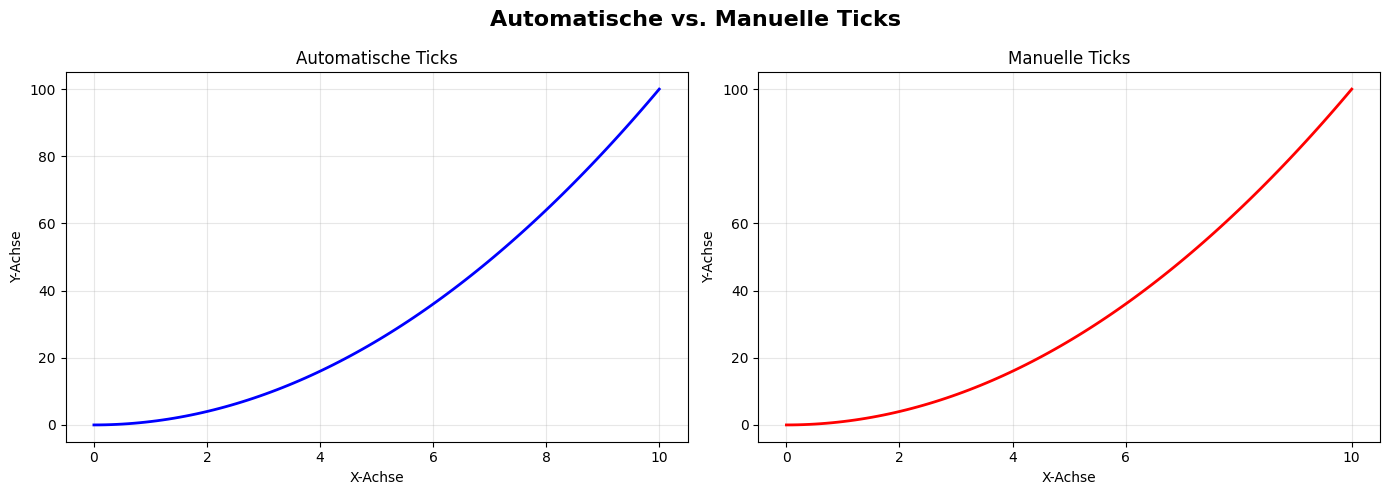


💡 Mit set_xticks() und set_yticks() kannst du Ticks manuell setzen!


In [23]:
# Beispiel: Ticks manuell setzen

x = np.linspace(0, 10, 100)
y = x ** 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Automatische vs. Manuelle Ticks', fontsize=16, weight='bold')

# Links: Automatische Ticks
ax1.plot(x, y, 'b-', linewidth=2)
ax1.set_title('Automatische Ticks', fontsize=12)
ax1.set_xlabel('X-Achse')
ax1.set_ylabel('Y-Achse')
ax1.grid(True, alpha=0.3)

print("Automatische Ticks:")
print(f"X: {ax1.get_xticks()}")
print(f"Y: {ax1.get_yticks()}\n")

# Rechts: Manuelle Ticks
ax2.plot(x, y, 'r-', linewidth=2)
ax2.set_xticks([0, 2, 4, 6, 10])  # ← Manuell gesetzt!
ax2.set_yticks([0, 20, 40, 60, 100])  # ← Manuell gesetzt!
ax2.set_title('Manuelle Ticks', fontsize=12)
ax2.set_xlabel('X-Achse')
ax2.set_ylabel('Y-Achse')
ax2.grid(True, alpha=0.3)

print("Manuelle Ticks:")
print(f"X: {ax2.get_xticks()}")
print(f"Y: {ax2.get_yticks()}")

plt.tight_layout()
plt.show()

print("\n💡 Mit set_xticks() und set_yticks() kannst du Ticks manuell setzen!")

### 6.3 Ticks mit `np.linspace()` erstellen

**Das ist der Trick!** Du kannst `np.linspace()` nutzen, um **gleichmäßig verteilte Ticks** zu erstellen.

#### Warum `linspace` für Ticks?

```python
# Problem: Ich will 5 gleichmäßige Ticks von 0 bis 100
# Lösung mit linspace:
ticks = np.linspace(0, 100, 5)  # [0, 25, 50, 75, 100]
ax.set_yticks(ticks)
```

#### Die Formel:

```python
np.linspace(start, stop, num)
#           ↑      ↑     ↑
#           |      |     Anzahl der Punkte
#           |      Endwert (inklusive!)
#           Startwert
```

#### Beispiele:

```python
# 5 Ticks von 0 bis 100
np.linspace(0, 100, 5)  # [0, 25, 50, 75, 100]

# 11 Ticks von 0 bis 10 (jede ganze Zahl)
np.linspace(0, 10, 11)  # [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# 6 Ticks von 0 bis 1 (für Prozent)
np.linspace(0, 1, 6)  # [0, 0.2, 0.4, 0.6, 0.8, 1.0]
```

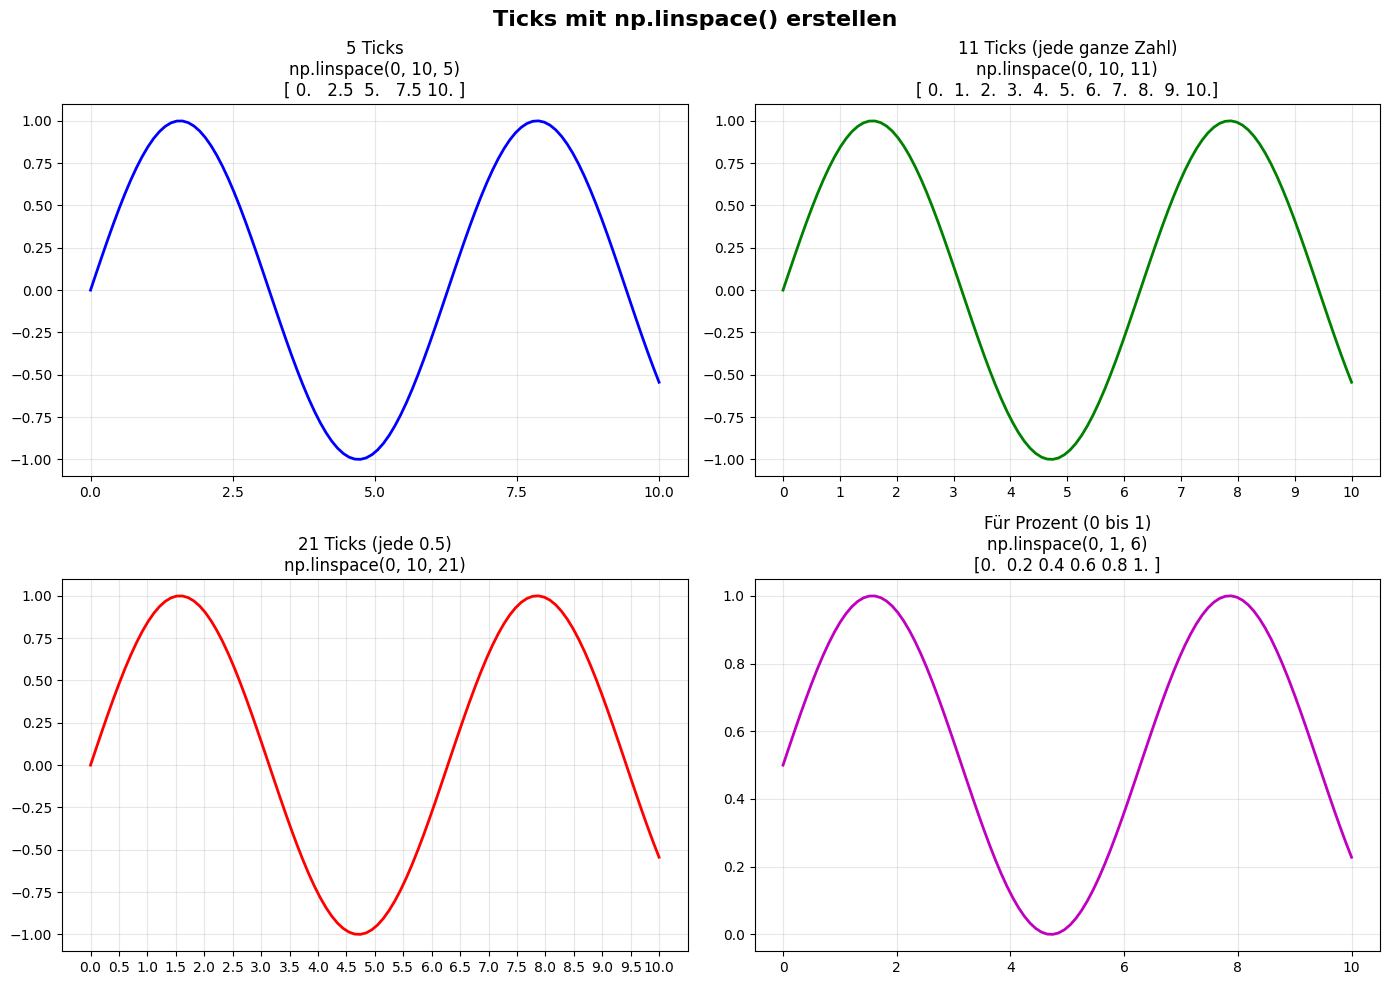


💡 np.linspace() ist perfekt für gleichmäßig verteilte Ticks!
   - np.linspace(0, 100, 5) → [0, 25, 50, 75, 100]
   - np.linspace(0, 10, 11) → [0, 1, 2, ..., 10]
   - np.linspace(0, 1, 6) → [0, 0.2, 0.4, 0.6, 0.8, 1.0]


In [10]:
# Beispiel: Ticks mit linspace erstellen

x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ticks mit np.linspace() erstellen', fontsize=16, weight='bold')

# 1. Wenige Ticks (5 Stück)
axes[0, 0].plot(x, y, 'b-', linewidth=2)
x_ticks_5 = np.linspace(0, 10, 5)
axes[0, 0].set_xticks(x_ticks_5)
axes[0, 0].set_title(f'5 Ticks\nnp.linspace(0, 10, 5)\n{x_ticks_5}')
axes[0, 0].grid(True, alpha=0.3)

# 2. Mittlere Anzahl (11 Ticks)
axes[0, 1].plot(x, y, 'g-', linewidth=2)
x_ticks_11 = np.linspace(0, 10, 11)
axes[0, 1].set_xticks(x_ticks_11)
axes[0, 1].set_title(f'11 Ticks (jede ganze Zahl)\nnp.linspace(0, 10, 11)\n{x_ticks_11}')
axes[0, 1].grid(True, alpha=0.3)

# 3. Viele Ticks (21 Stück)
axes[1, 0].plot(x, y, 'r-', linewidth=2)
x_ticks_21 = np.linspace(0, 10, 21)
axes[1, 0].set_xticks(x_ticks_21)
axes[1, 0].set_title(f'21 Ticks (jede 0.5)\nnp.linspace(0, 10, 21)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Für Prozent (6 Ticks von 0 bis 1)
axes[1, 1].plot(x, (y + 1) / 2, 'm-', linewidth=2)  # Normalisiert auf 0-1
y_ticks_percent = np.linspace(0, 1, 6)
axes[1, 1].set_yticks(y_ticks_percent)
axes[1, 1].set_title(f'Für Prozent (0 bis 1)\nnp.linspace(0, 1, 6)\n{y_ticks_percent}')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 np.linspace() ist perfekt für gleichmäßig verteilte Ticks!")
print("   - np.linspace(0, 100, 5) → [0, 25, 50, 75, 100]")
print("   - np.linspace(0, 10, 11) → [0, 1, 2, ..., 10]")
print("   - np.linspace(0, 1, 6) → [0, 0.2, 0.4, 0.6, 0.8, 1.0]")

### 6.4 Tick-Labels anpassen

**Tick-Labels** sind die **Texte** neben den Ticks. Du kannst sie anpassen, um:
- **Prozent** anzuzeigen (0%, 25%, 50%)
- **Währungen** zu zeigen (0€, 50€, 100€)
- **Einheiten** hinzuzufügen (0 km, 50 km, 100 km)
- **Eigene Texte** zu verwenden ("Niedrig", "Mittel", "Hoch")

#### Methode 1: Mit Liste

```python
# 1. Ticks setzen
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])

# 2. Labels anpassen
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
```

#### Methode 2: Mit List Comprehension

```python
ticks = np.linspace(0, 1, 5)
ax.set_yticks(ticks)
ax.set_yticklabels([f'{int(t*100)}%' for t in ticks])
```

#### Wichtig:

- Die **Anzahl der Labels** muss mit der **Anzahl der Ticks** übereinstimmen!
- Erst `set_xticks()`, dann `set_xticklabels()`

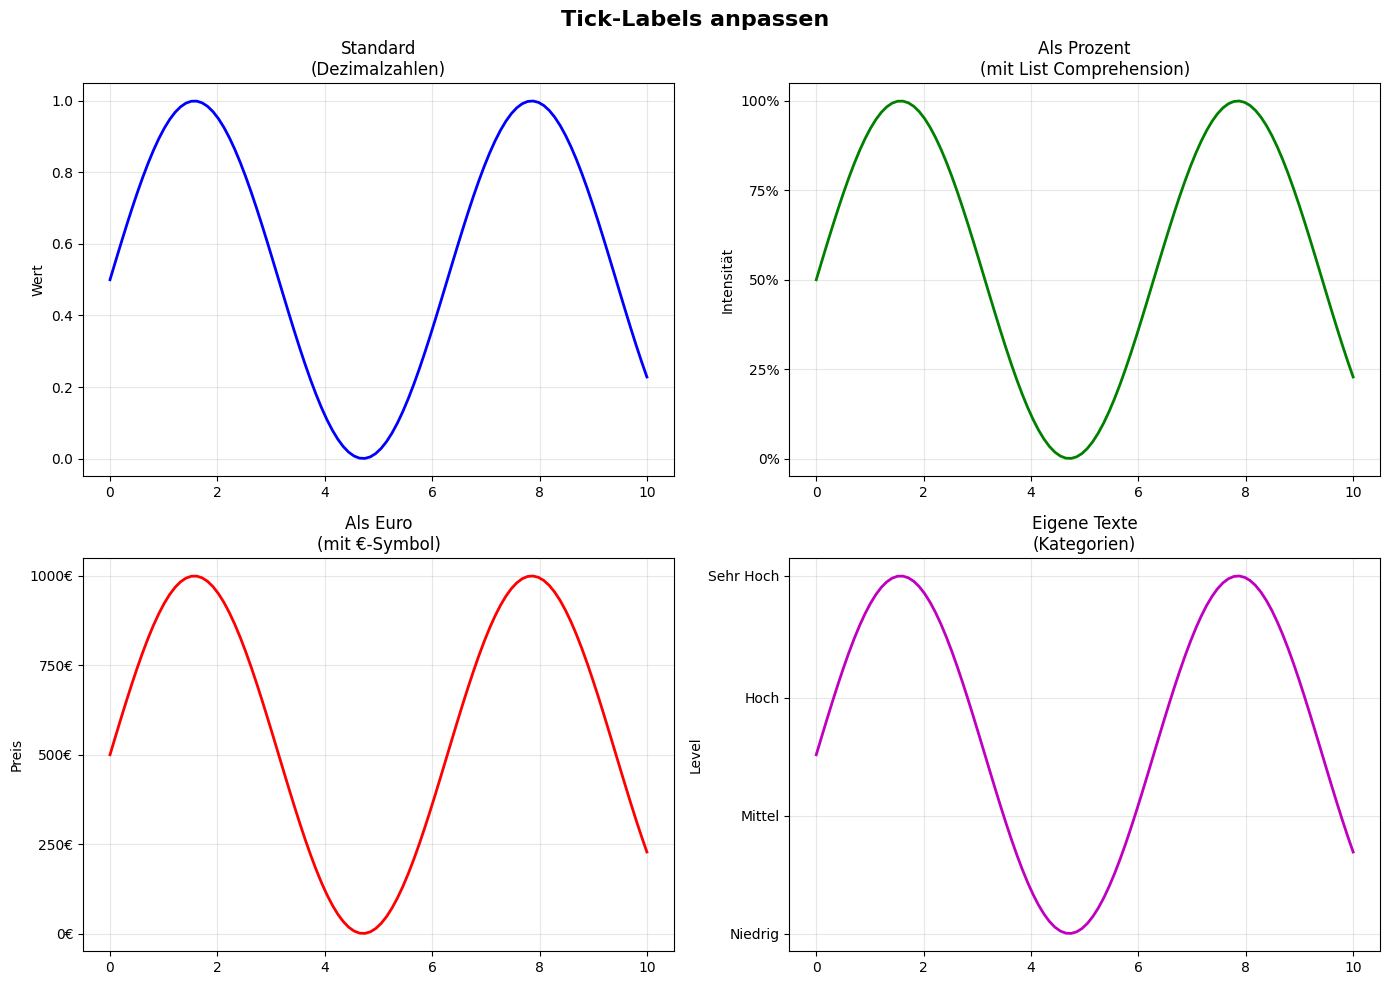


💡 Tick-Labels anpassen:
   1. Ticks setzen: ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
   2. Labels ändern: ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])
   3. Oder mit List Comprehension: [f'{int(t*100)}%' for t in ticks]


In [11]:
# Beispiel: Tick-Labels anpassen

x = np.linspace(0, 10, 100)
y = np.sin(x) * 0.5 + 0.5  # Werte zwischen 0 und 1

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Tick-Labels anpassen', fontsize=16, weight='bold')

# 1. Standard (Dezimalzahlen)
axes[0, 0].plot(x, y, 'b-', linewidth=2)
axes[0, 0].set_title('Standard\n(Dezimalzahlen)', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylabel('Wert')

# 2. Als Prozent (mit List Comprehension)
axes[0, 1].plot(x, y, 'g-', linewidth=2)
y_ticks = np.linspace(0, 1, 5)
axes[0, 1].set_yticks(y_ticks)
axes[0, 1].set_yticklabels([f'{int(t*100)}%' for t in y_ticks])
axes[0, 1].set_title('Als Prozent\n(mit List Comprehension)', fontsize=12)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylabel('Intensität')

# 3. Als Euro
axes[1, 0].plot(x, y * 1000, 'r-', linewidth=2)
y_ticks_euro = np.linspace(0, 1000, 5)
axes[1, 0].set_yticks(y_ticks_euro)
axes[1, 0].set_yticklabels([f'{int(t)}€' for t in y_ticks_euro])
axes[1, 0].set_title('Als Euro\n(mit €-Symbol)', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylabel('Preis')

# 4. Eigene Texte
axes[1, 1].plot(x, y, 'm-', linewidth=2)
axes[1, 1].set_yticks([0, 0.33, 0.66, 1.0])
axes[1, 1].set_yticklabels(['Niedrig', 'Mittel', 'Hoch', 'Sehr Hoch'])
axes[1, 1].set_title('Eigene Texte\n(Kategorien)', fontsize=12)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylabel('Level')

plt.tight_layout()
plt.show()

print("\n💡 Tick-Labels anpassen:")
print("   1. Ticks setzen: ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])")
print("   2. Labels ändern: ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])")
print("   3. Oder mit List Comprehension: [f'{int(t*100)}%' for t in ticks]")

### 6.5 Praktisches Beispiel: Intensity Chart mit Ticks

Jetzt kombinieren wir alles, was wir gelernt haben, um einen professionellen Plot zu erstellen:

1. **Ticks mit `linspace` erstellen**
2. **Tick-Labels als Prozent formatieren**
3. **Styling anpassen**

### 6.6 Zusammenfassung: Ticks

#### Was sind Ticks?
- **Markierungen** auf den Achsen
- Bestehen aus **Position** (wo) und **Label** (was steht da)
- Helfen beim **Ablesen** von Werten

#### Automatische Ticks:
```python
# Matplotlib setzt automatisch Ticks
ax.plot(x, y)
# Ticks werden basierend auf Daten gewählt
```

#### Manuelle Ticks:
```python
# Mit Liste
ax.set_xticks([0, 1, 2, 3, 4, 5])
ax.set_yticks([0, 25, 50, 75, 100])
```

#### Ticks mit linspace:
```python
# Gleichmäßig verteilte Ticks
x_ticks = np.linspace(0, 10, 11)  # 0, 1, 2, ..., 10
y_ticks = np.linspace(0, 1, 5)    # 0, 0.25, 0.5, 0.75, 1.0
ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
```

#### Tick-Labels anpassen:
```python
# Methode 1: Mit Liste
ax.set_yticklabels(['0%', '25%', '50%', '75%', '100%'])

# Methode 2: Mit List Comprehension
ax.set_yticklabels([f'{int(t*100)}%' for t in y_ticks])
```

#### Der typische Workflow:
```python
# 1. Ticks mit linspace erstellen
y_ticks = np.linspace(0, 1, 5)

# 2. Ticks setzen
ax.set_yticks(y_ticks)

# 3. Labels formatieren
ax.set_yticklabels([f'{int(t*100)}%' for t in y_ticks])
```

#### Wichtige Regeln:
- ✅ Erst `set_xticks()`, dann `set_xticklabels()`
- ✅ Anzahl Labels = Anzahl Ticks
- ✅ `linspace` für gleichmäßige Verteilung
- ✅ List Comprehension für dynamische Labels

### Visualisierung: Warum mehr Punkte = glattere Kurven

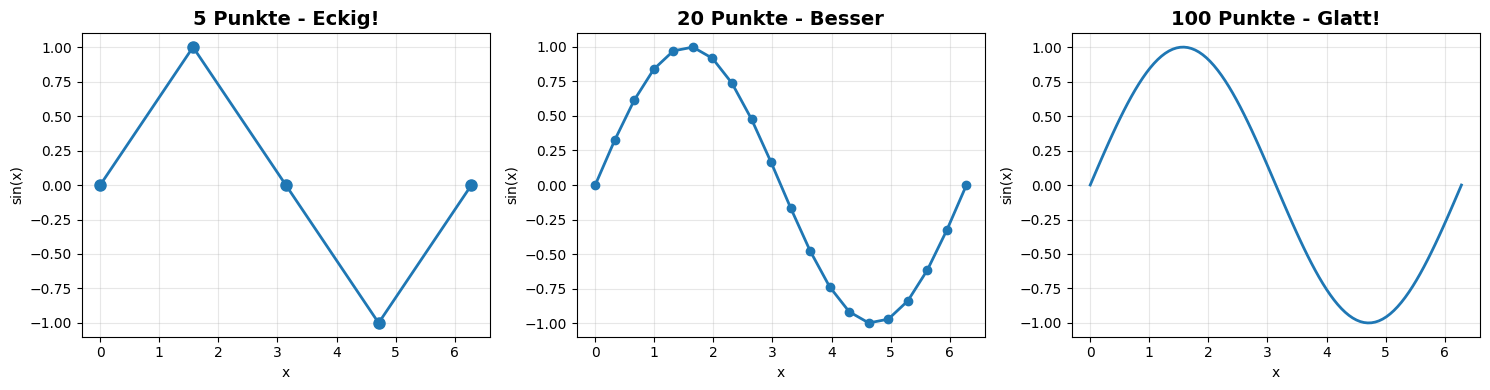


💡 Fazit: Mehr Punkte = glattere Kurven!
   Für unsere Wachstumskurve nutzen wir 100 Punkte.


In [12]:
# Erstelle eine Sinuskurve mit unterschiedlich vielen Punkten
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

# Mit 5 Punkten - sehr eckig!
x1 = np.linspace(0, 2*np.pi, 5)
y1 = np.sin(x1)
ax1.plot(x1, y1, 'o-', linewidth=2, markersize=8)
ax1.set_title('5 Punkte - Eckig!', fontsize=14, weight='bold')
ax1.set_xlabel('x')
ax1.set_ylabel('sin(x)')
ax1.grid(True, alpha=0.3)

# Mit 20 Punkten - besser
x2 = np.linspace(0, 2*np.pi, 20)
y2 = np.sin(x2)
ax2.plot(x2, y2, 'o-', linewidth=2, markersize=6)
ax2.set_title('20 Punkte - Besser', fontsize=14, weight='bold')
ax2.set_xlabel('x')
ax2.set_ylabel('sin(x)')
ax2.grid(True, alpha=0.3)

# Mit 100 Punkten - glatt!
x3 = np.linspace(0, 2*np.pi, 100)
y3 = np.sin(x3)
ax3.plot(x3, y3, linewidth=2)
ax3.set_title('100 Punkte - Glatt!', fontsize=14, weight='bold')
ax3.set_xlabel('x')
ax3.set_ylabel('sin(x)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Fazit: Mehr Punkte = glattere Kurven!")
print("   Für unsere Wachstumskurve nutzen wir 100 Punkte.")

### Beispiel: Eine Figure mit mehreren Axes (Subplots)

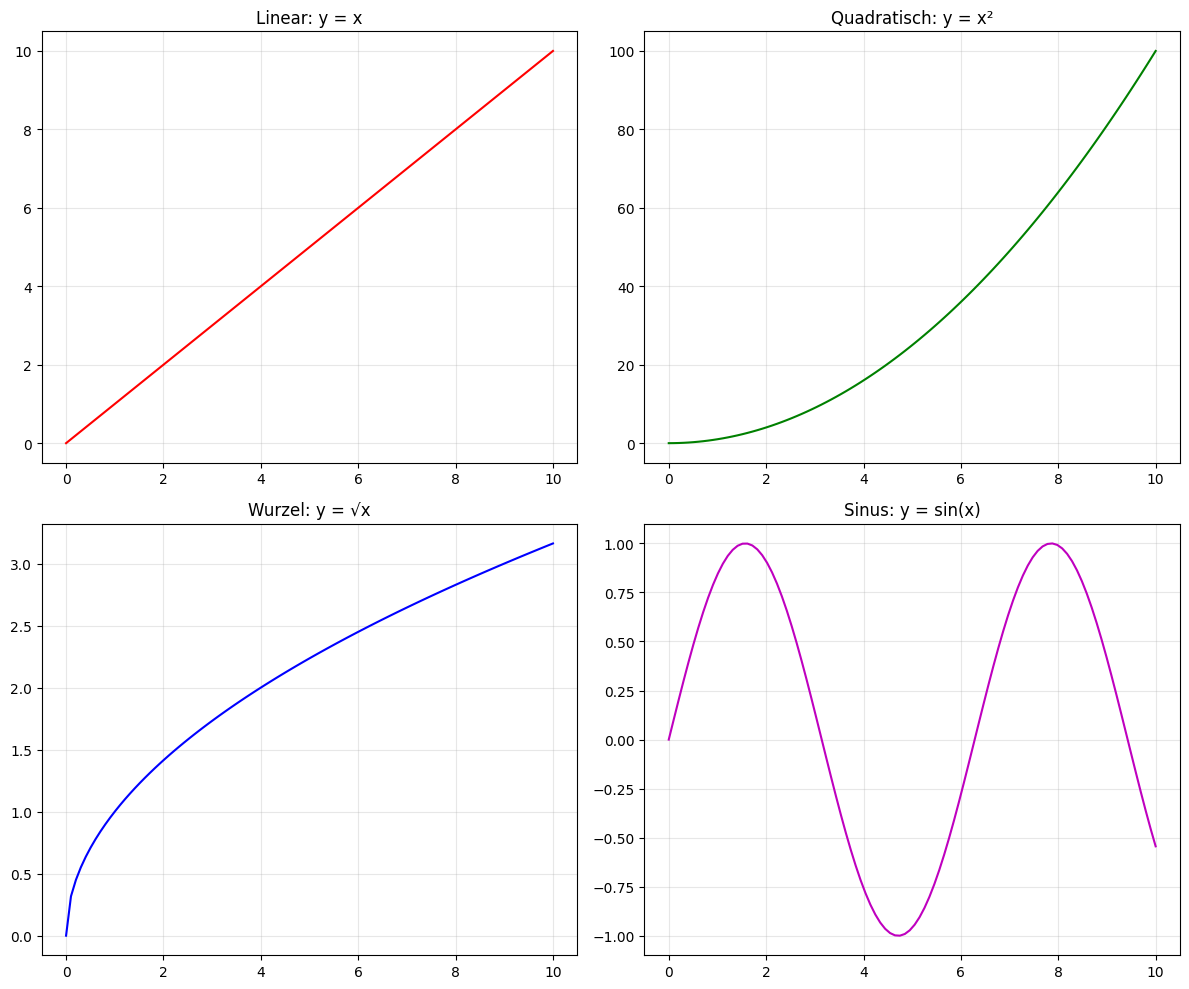


💡 Eine Figure kann mehrere Axes enthalten!
   Jedes Axes ist ein unabhängiger Plot-Bereich.


In [13]:
# Eine Figure mit 4 Axes (2x2 Grid)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 10))

# Jedes Axes ist ein separater Plot-Bereich
x = np.linspace(0, 10, 100)

ax1.plot(x, x, 'r-')
ax1.set_title('Linear: y = x')
ax1.grid(True, alpha=0.3)

ax2.plot(x, x**2, 'g-')
ax2.set_title('Quadratisch: y = x²')
ax2.grid(True, alpha=0.3)

ax3.plot(x, np.sqrt(x), 'b-')
ax3.set_title('Wurzel: y = √x')
ax3.grid(True, alpha=0.3)

ax4.plot(x, np.sin(x), 'm-')
ax4.set_title('Sinus: y = sin(x)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Eine Figure kann mehrere Axes enthalten!")
print("   Jedes Axes ist ein unabhängiger Plot-Bereich.")

Unsere Daten:
x: [1 2 3 4 5]
y: [10 25 15 30 20]

x min: 1, x max: 5
y min: 10, y max: 30

Automatisch gesetzte Grenzen:
x-Achse: 0.80 bis 5.20
y-Achse: 9.00 bis 31.00


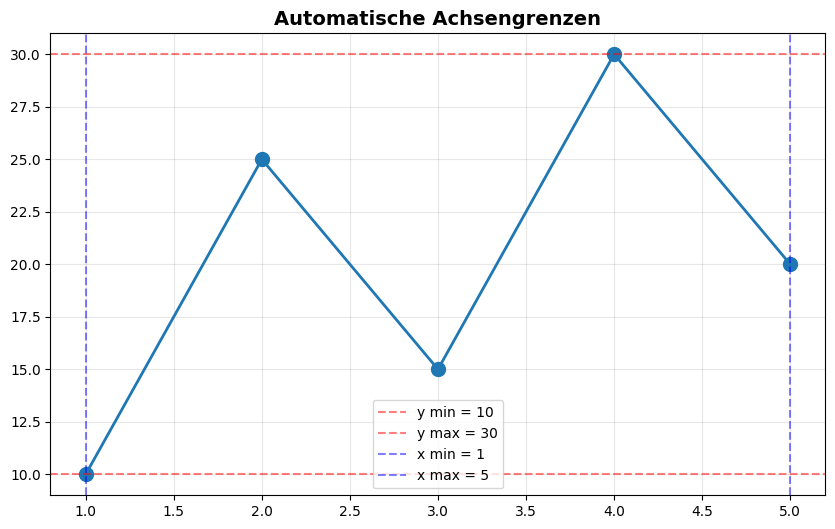


💡 Matplotlib fügt automatisch einen kleinen Puffer hinzu!
   Die Achsen gehen etwas über die Datengrenzen hinaus.


In [14]:
# Beispiel: Automatische Achsengrenzen
x = np.array([1, 2, 3, 4, 5])
y = np.array([10, 25, 15, 30, 20])

print("Unsere Daten:")
print(f"x: {x}")
print(f"y: {y}")
print(f"\nx min: {x.min()}, x max: {x.max()}")
print(f"y min: {y.min()}, y max: {y.max()}")

# Plot mit automatischen Achsengrenzen
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, 'o-', linewidth=2, markersize=10)
ax.set_title('Automatische Achsengrenzen', fontsize=14, weight='bold')
ax.grid(True, alpha=0.3)

# Zeige die automatisch gesetzten Grenzen
xlim = ax.get_xlim()
ylim = ax.get_ylim()

print(f"\nAutomatisch gesetzte Grenzen:")
print(f"x-Achse: {xlim[0]:.2f} bis {xlim[1]:.2f}")
print(f"y-Achse: {ylim[0]:.2f} bis {ylim[1]:.2f}")

# Markiere die Datengrenzen
ax.axhline(y.min(), color='red', linestyle='--', alpha=0.5, label=f'y min = {y.min()}')
ax.axhline(y.max(), color='red', linestyle='--', alpha=0.5, label=f'y max = {y.max()}')
ax.axvline(x.min(), color='blue', linestyle='--', alpha=0.5, label=f'x min = {x.min()}')
ax.axvline(x.max(), color='blue', linestyle='--', alpha=0.5, label=f'x max = {x.max()}')
ax.legend()

plt.show()

print("\n💡 Matplotlib fügt automatisch einen kleinen Puffer hinzu!")
print("   Die Achsen gehen etwas über die Datengrenzen hinaus.")

### Manuelle Kontrolle der Achsengrenzen

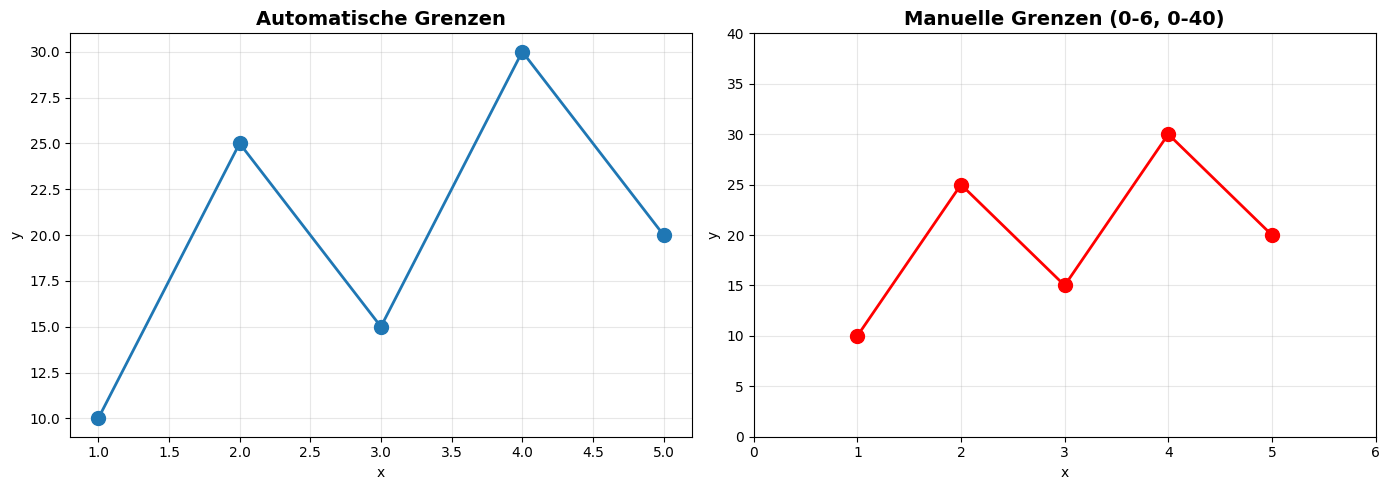


💡 Mit set_xlim() und set_ylim() kannst du die Grenzen manuell setzen!
   Das ist nützlich, wenn du die Darstellung kontrollieren willst.


In [15]:
# Vergleich: Automatisch vs. Manuell
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = np.array([1, 2, 3, 4, 5])
y = np.array([10, 25, 15, 30, 20])

# Links: Automatisch
ax1.plot(x, y, 'o-', linewidth=2, markersize=10)
ax1.set_title('Automatische Grenzen', fontsize=14, weight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xlabel('x')
ax1.set_ylabel('y')

# Rechts: Manuell gesetzt
ax2.plot(x, y, 'o-', linewidth=2, markersize=10, color='red')
ax2.set_xlim(0, 6)  # Manuell: 0 bis 6
ax2.set_ylim(0, 40)  # Manuell: 0 bis 40
ax2.set_title('Manuelle Grenzen (0-6, 0-40)', fontsize=14, weight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('x')
ax2.set_ylabel('y')

plt.tight_layout()
plt.show()

print("\n💡 Mit set_xlim() und set_ylim() kannst du die Grenzen manuell setzen!")
print("   Das ist nützlich, wenn du die Darstellung kontrollieren willst.")

## 4. Arrays vs. Listen - Warum kein einfaches "Mapping"?

### Die Frage:
Warum kann man ein NumPy Array nicht einfach wie eine Python-Liste mit `map()` bearbeiten?

### Die Antwort:
NumPy Arrays sind **fundamental anders** als Python-Listen:

1. **Arrays sind homogen** (alle Elemente gleicher Typ)
2. **Arrays sind optimiert** für numerische Operationen
3. **Arrays unterstützen Vektorisierung** (Operationen auf allen Elementen gleichzeitig)

### Schauen wir uns die Unterschiede an:

In [16]:
# Python Liste
python_liste = [1, 2, 3, 4, 5]
print("Python Liste:")
print(f"Typ: {type(python_liste)}")
print(f"Inhalt: {python_liste}")

# NumPy Array
numpy_array = np.array([1, 2, 3, 4, 5])
print("\nNumPy Array:")
print(f"Typ: {type(numpy_array)}")
print(f"Inhalt: {numpy_array}")
print(f"Datentyp der Elemente: {numpy_array.dtype}")
print(f"Shape: {numpy_array.shape}")

Python Liste:
Typ: <class 'list'>
Inhalt: [1, 2, 3, 4, 5]

NumPy Array:
Typ: <class 'numpy.ndarray'>
Inhalt: [1 2 3 4 5]
Datentyp der Elemente: int64
Shape: (5,)


### Unterschied 1: Operationen auf allen Elementen

In [17]:
# Mit Python Liste - braucht map() oder List Comprehension
python_liste = [1, 2, 3, 4, 5]

# Methode 1: List Comprehension
verdoppelt_liste = [x * 2 for x in python_liste]
print("Python Liste verdoppelt (List Comprehension):")
print(verdoppelt_liste)

# Methode 2: map()
verdoppelt_map = list(map(lambda x: x * 2, python_liste))
print("\nPython Liste verdoppelt (map):")
print(verdoppelt_map)

print("\n" + "="*60)

# Mit NumPy Array - direkte Operation!
numpy_array = np.array([1, 2, 3, 4, 5])
verdoppelt_array = numpy_array * 2  # ✨ Vektorisierte Operation!
print("\nNumPy Array verdoppelt (direkt):")
print(verdoppelt_array)

print("\n💡 NumPy Arrays unterstützen direkte Operationen auf allen Elementen!")
print("   Das nennt man 'Vektorisierung' - viel schneller als map()!")

Python Liste verdoppelt (List Comprehension):
[2, 4, 6, 8, 10]

Python Liste verdoppelt (map):
[2, 4, 6, 8, 10]


NumPy Array verdoppelt (direkt):
[ 2  4  6  8 10]

💡 NumPy Arrays unterstützen direkte Operationen auf allen Elementen!
   Das nennt man 'Vektorisierung' - viel schneller als map()!


### Unterschied 2: Mathematische Operationen

In [18]:
# Python Liste - funktioniert NICHT direkt
python_liste = [1, 2, 3, 4, 5]

print("❌ Python Liste * 2 funktioniert nicht wie erwartet!")
print(f"   Ergebnis: {python_liste * 2}")
print("   (Liste wird wiederholt, nicht multipliziert!)")

print("\n" + "="*60 + "\n")

# NumPy Array - funktioniert perfekt!
numpy_array = np.array([1, 2, 3, 4, 5])
print("✅ NumPy Array * 2:")
print(numpy_array * 2)

print("\n✅ NumPy Array + 10:")
print(numpy_array + 10)

print("\n✅ NumPy Array ** 2 (Quadrat):")
print(numpy_array ** 2)

print("\n✅ NumPy Array / 2:")
print(numpy_array / 2)

❌ Python Liste * 2 funktioniert nicht wie erwartet!
   Ergebnis: [1, 2, 3, 4, 5, 1, 2, 3, 4, 5]
   (Liste wird wiederholt, nicht multipliziert!)


✅ NumPy Array * 2:
[ 2  4  6  8 10]

✅ NumPy Array + 10:
[11 12 13 14 15]

✅ NumPy Array ** 2 (Quadrat):
[ 1  4  9 16 25]

✅ NumPy Array / 2:
[0.5 1.  1.5 2.  2.5]


### Unterschied 3: Mathematische Funktionen

In [19]:
# NumPy bietet viele mathematische Funktionen
x = np.array([0, 1, 2, 3, 4, 5])

print("Original Array:")
print(x)

print("\nMathematische Funktionen:")
print(f"Quadratwurzel: {np.sqrt(x)}")
print(f"Exponential: {np.exp(x)}")
print(f"Logarithmus: {np.log(x[1:])}  # (ohne 0, da log(0) undefiniert)")
print(f"Sinus: {np.sin(x)}")

print("\n💡 Diese Funktionen arbeiten auf dem gesamten Array gleichzeitig!")
print("   Mit Python-Listen bräuchtest du map() oder eine Schleife.")

Original Array:
[0 1 2 3 4 5]

Mathematische Funktionen:
Quadratwurzel: [0.         1.         1.41421356 1.73205081 2.         2.23606798]
Exponential: [  1.           2.71828183   7.3890561   20.08553692  54.59815003
 148.4131591 ]
Logarithmus: [0.         0.69314718 1.09861229 1.38629436 1.60943791]  # (ohne 0, da log(0) undefiniert)
Sinus: [ 0.          0.84147098  0.90929743  0.14112001 -0.7568025  -0.95892427]

💡 Diese Funktionen arbeiten auf dem gesamten Array gleichzeitig!
   Mit Python-Listen bräuchtest du map() oder eine Schleife.


Performance-Vergleich (1,000,000 Elemente):

Python Liste (List Comprehension): 0.0159 Sekunden
NumPy Array (Vektorisierung):      0.0006 Sekunden

🚀 NumPy ist 24.5x schneller!


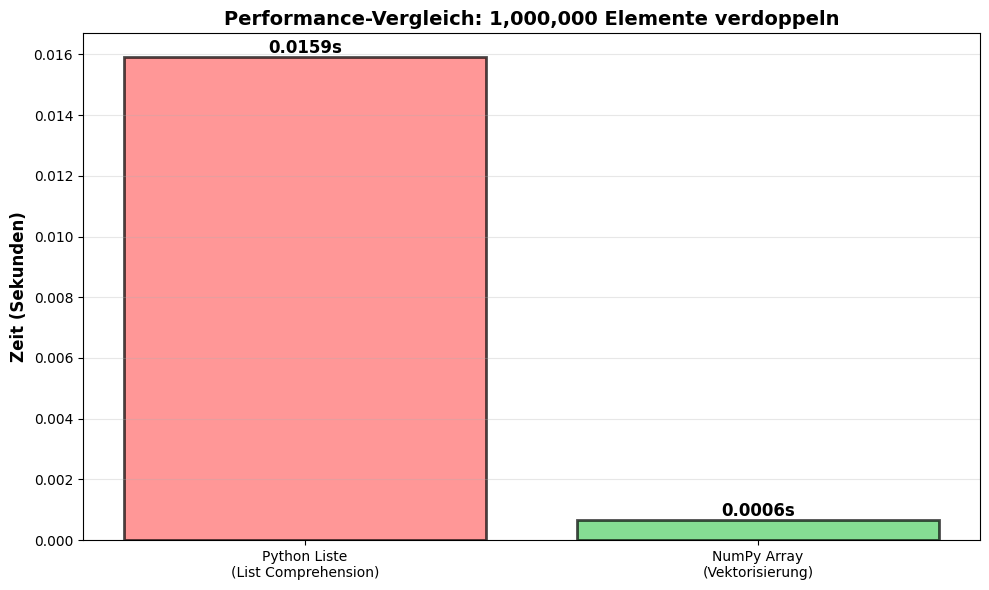

In [20]:
import time

# Große Datenmenge
size = 1000000
python_liste = list(range(size))
numpy_array = np.arange(size)

# Test 1: Python Liste mit List Comprehension
start = time.time()
result_liste = [x * 2 for x in python_liste]
zeit_liste = time.time() - start

# Test 2: NumPy Array mit Vektorisierung
start = time.time()
result_array = numpy_array * 2
zeit_array = time.time() - start

print(f"Performance-Vergleich ({size:,} Elemente):")
print(f"\nPython Liste (List Comprehension): {zeit_liste:.4f} Sekunden")
print(f"NumPy Array (Vektorisierung):      {zeit_array:.4f} Sekunden")
print(f"\n🚀 NumPy ist {zeit_liste/zeit_array:.1f}x schneller!")

# Visualisierung
fig, ax = plt.subplots(figsize=(10, 6))
methoden = ['Python Liste\n(List Comprehension)', 'NumPy Array\n(Vektorisierung)']
zeiten = [zeit_liste, zeit_array]
colors = ['#ff6b6b', '#51cf66']

bars = ax.bar(methoden, zeiten, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('Zeit (Sekunden)', fontsize=12, weight='bold')
ax.set_title(f'Performance-Vergleich: {size:,} Elemente verdoppeln', 
             fontsize=14, weight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Werte auf den Balken
for bar, zeit in zip(bars, zeiten):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{zeit:.4f}s',
            ha='center', va='bottom', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

## Zusammenfassung: Warum NumPy Arrays?

### Vorteile von NumPy Arrays:

1. **Vektorisierung**: Operationen auf allen Elementen gleichzeitig
2. **Performance**: Viel schneller als Python-Listen
3. **Mathematische Funktionen**: Eingebaute Funktionen für wissenschaftliches Rechnen
4. **Speichereffizienz**: Kompaktere Speicherung
5. **Broadcasting**: Intelligente Operationen zwischen Arrays verschiedener Größen

### Wann welche Methode?

```python
# ✅ NumPy Array - Für numerische Daten und Berechnungen
x = np.array([1, 2, 3, 4, 5])
y = x * 2  # Direkte Operation

# ✅ Python Liste - Für gemischte Datentypen oder nicht-numerische Daten
mixed = [1, "text", 3.14, True]
processed = [process(item) for item in mixed]  # List Comprehension

# ❌ NICHT empfohlen - map() auf NumPy Arrays
# Nutze stattdessen Vektorisierung!
```

## Praktisches Beispiel: Unsere Wachstumskurve

Jetzt verstehen wir, warum wir in unserem Intensity Chart so vorgehen:

X-Werte (erste 10):
[31.         31.01515152 31.03030303 31.04545455 31.06060606 31.07575758
 31.09090909 31.10606061 31.12121212 31.13636364]

Y-Werte (erste 10):
[50.         52.94030299 55.70769835 58.3123541  60.7638403  63.07116425
 65.24280358 67.28673735 69.21047544 71.02108606]

Automatische Achsengrenzen:
X-Achse: (30.925, 32.575)
Y-Achse: (47.506196880441664, 102.36986551072502)


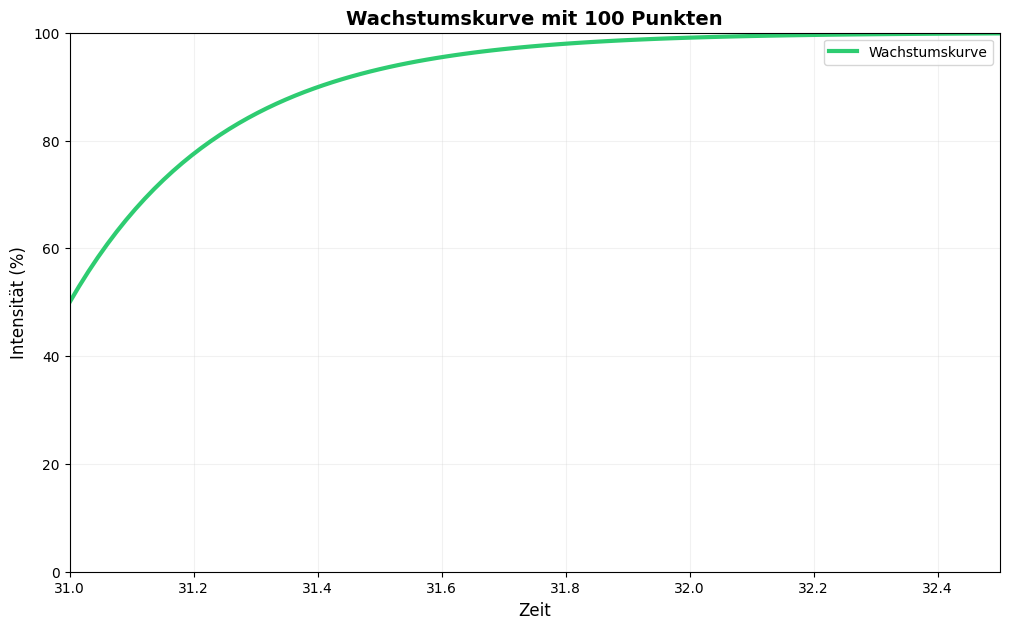


💡 Alles zusammen:
   1. linspace() für gleichmäßige Punkte
   2. Vektorisierte Berechnung mit NumPy
   3. Figure und Axes für die Struktur
   4. Automatische oder manuelle Achsengrenzen
   5. plt.show() zum Anzeigen (NICHT fig.show()!)


In [21]:
# 1. Erstelle gleichmäßig verteilte x-Werte mit linspace
growth_x = np.linspace(31, 32.5, 100)  # 100 Punkte für glatte Kurve
print("X-Werte (erste 10):")
print(growth_x[:10])

# 2. Berechne y-Werte mit vektorisierter Operation
# Exponentialfunktion: y = 50 + 50 * (1 - exp(-4 * (x - 31)))
growth_y = 50 + 50 * (1 - np.exp(-4 * (growth_x - 31)))
print("\nY-Werte (erste 10):")
print(growth_y[:10])

# 3. Erstelle Figure und Axes
fig, ax = plt.subplots(figsize=(12, 7), facecolor='white')
ax.set_facecolor('white')

# 4. Plotte die Kurve
ax.plot(growth_x, growth_y, color='#2ecc71', linewidth=3, label='Wachstumskurve')

# 5. Matplotlib setzt automatisch die Achsengrenzen basierend auf den Daten
print(f"\nAutomatische Achsengrenzen:")
print(f"X-Achse: {ax.get_xlim()}")
print(f"Y-Achse: {ax.get_ylim()}")

# 6. Wir können sie aber auch manuell setzen
ax.set_xlim(31, 32.5)
ax.set_ylim(0, 100)

# Styling
ax.set_xlabel('Zeit', fontsize=12)
ax.set_ylabel('Intensität (%)', fontsize=12)
ax.set_title('Wachstumskurve mit 100 Punkten', fontsize=14, weight='bold')
ax.grid(True, alpha=0.3, color='#d3d3d3')
ax.legend()

# 7. Zeige mit plt.show() (nicht fig.show()!)
plt.show()

print("\n💡 Alles zusammen:")
print("   1. linspace() für gleichmäßige Punkte")
print("   2. Vektorisierte Berechnung mit NumPy")
print("   3. Figure und Axes für die Struktur")
print("   4. Automatische oder manuelle Achsengrenzen")
print("   5. plt.show() zum Anzeigen (NICHT fig.show()!)")

### Performance-Vergleich: Array vs. Liste

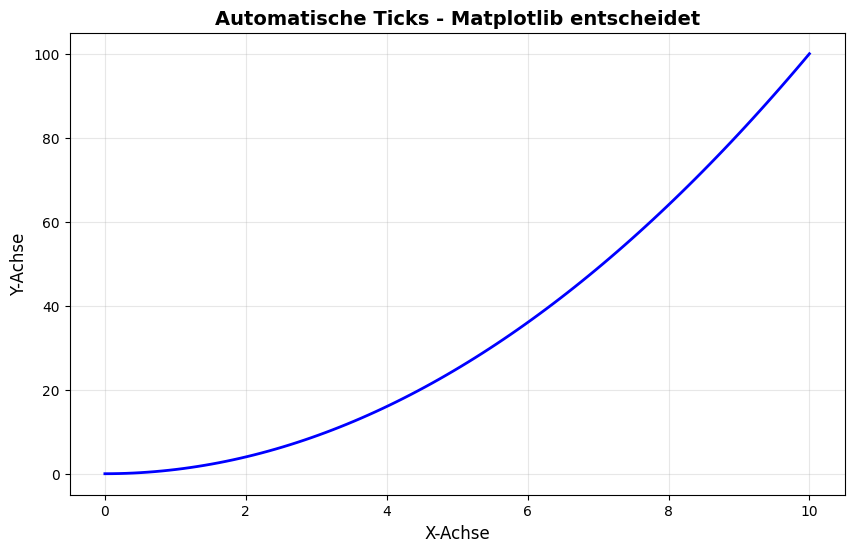

Automatisch gewählte Ticks:
X-Ticks: [-2.  0.  2.  4.  6.  8. 10. 12.]
Y-Ticks: [-20.   0.  20.  40.  60.  80. 100. 120.]

💡 Matplotlib wählt automatisch runde, sinnvolle Werte!


In [22]:
# Beispiel: Automatische Ticks

x = np.linspace(0, 10, 100)
y = x ** 2

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, y, 'b-', linewidth=2)
ax.set_title('Automatische Ticks - Matplotlib entscheidet', fontsize=14, weight='bold')
ax.set_xlabel('X-Achse', fontsize=12)
ax.set_ylabel('Y-Achse', fontsize=12)
ax.grid(True, alpha=0.3)

plt.show()

# Welche Ticks hat Matplotlib gewählt?
print("Automatisch gewählte Ticks:")
print(f"X-Ticks: {ax.get_xticks()}")
print(f"Y-Ticks: {ax.get_yticks()}")
print("\n💡 Matplotlib wählt automatisch runde, sinnvolle Werte!")

## Abschluss-Quiz: Hast du alles verstanden?

Beantworte diese Fragen für dich selbst:

1. **Warum `plt.show()` statt `fig.show()`?**
   - `plt.show()` ist die offizielle Methode, verwaltet alle Figures, schließt sie automatisch

2. **Was macht `np.linspace(0, 10, 50)`?**
   - Erstellt 50 gleichmäßig verteilte Punkte zwischen 0 und 10

3. **Was ist der Unterschied zwischen Figure und Axes?**
   - Figure = gesamtes Bild, Axes = Plot-Bereich mit Koordinatensystem

4. **Wie setzt Matplotlib die Achsengrenzen?**
   - Automatisch basierend auf Min/Max der Daten (mit Puffer)

5. **Warum NumPy Arrays statt Python-Listen?**
   - Vektorisierung, Performance, mathematische Funktionen

6. **Kann man `map()` auf NumPy Arrays verwenden?**
   - Ja, aber nicht empfohlen - nutze Vektorisierung stattdessen!